This is a notebook to experiment with the different keywords that can be used to associate the subjects of circulars with event types.

GCN Classic had 4 source types available: GRB (gamma ray burst), GW (gravitational waves), SGR (soft gamma-ray repeaters), and misc, with misc being a catch-all for anything that didn't fit into the other categories. 

## Step 1: Loading the data

In [47]:
import json
import re
import matplotlib.pyplot as plt
from collections import Counter

subjects = json.load(open("circulars.json", "r"))
subjects = [item["subject"] for item in subjects.values()]
subjects

['LIGO/Virgo/KAGRA S231206cc: Identification of a GW compact binary merger candidate',
 'GRB 180111A: AGILE/MCAL detection',
 'GRB 061021: Swift/UVOT Observation',
 'GRB 221028A: NUTTelA-TAO / BSTI Early Optical Limits',
 'LIGO/Virgo G275697: Further Swift-XRT sources',
 'LIGO/Virgo/KAGRA S240422ed: Magellan Observations',
 'Konus-Wind observation of GRB 180113B',
 'GRB 050724: Chandra Observations of the X-ray Afterglow',
 'Chandra observations of GW170817 at 2.5 years since merger (All epochs 4 of 4)',
 'GRB 221027B: FRAM-ORM and Ondrejov SBT optical limits',
 'GRB 141028A: Swift/UVOT followup observations',
 'GRB 111222A, the review of the sky area in plate archives',
 'GRB991216 late optical observation',
 'GRB 200412B: continued Terskol optical observations',
 'GRB 251001B: Further GOTO observations of optical counterpart.',
 'GRB 060605: SkyNet Optical Limits',
 'GRB141207A: Discovery Channel Telescope Optical Observations',
 'GRB 190220B: a long GRB detected by IBAS',
 'GRB 0602

Next we must determine what keywords to associate with each event type. To do this, we will load the data and analyze the subjects of the circulars.

Total Circulars:  43843
{'GRB': 38840, 'GW': 3609, 'SGR': 542, 'FRB': 32, 'SN': 242, 'AGN': 8, 'Neutrino': 1572, 'X-Ray Transient': 2168, 'Afterglow': 2430, 'Optical Transient': 9798, 'Retraction': 745, 'misc': 82}


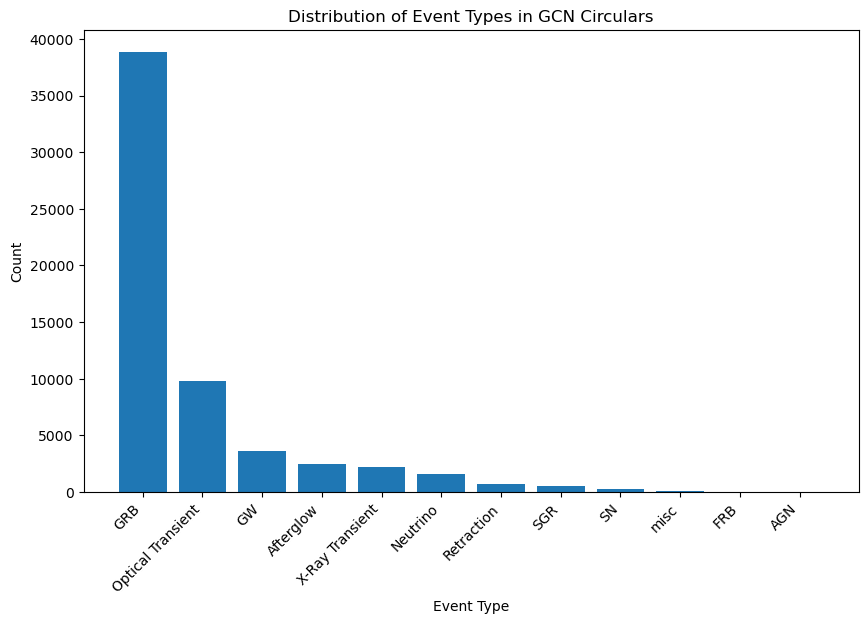

In [78]:
event_keywords = {
    "GRB": [
        r"GRB\d{6}[A-Z]?",
        "GRB",
        "GRBs"
        "gamma ray burst",
        "gamma-ray burst",
        "Fermi",
        r"Fermi\d{9}",
        "Swift",
        "SVOM",
        "INTEGRAL",
        "XRF",
        "MASTER",
        "HAWC",
        "HETE",
        r"XRF\d{6}[A-Z]?",
    ],
    "GW": [
        r"GW\d+",
        "GW",
        "gravitational wave",
        "gravitational-wave",
        "LIGO",
        "Virgo",
        "KAGRA",
    ],
    "SGR": [
        r"SGR\d+(?:[+-]\d+)?",
        r"SGR\S+",
        "SGR",
        "soft gamma-ray repeater",
        "soft gamma ray",
    ],
    "FRB": [
        r"FRB\d{6}[A-Z]?",
        "FRB",
        "fast radio burst",
        "fast-radio burst",
    ],
    "SN": [
        r"SN\d{4}[A-Za-z]*",
        "SN",
        "supernova",
        "super nova",
    ],
    "AGN": [
        "AGN", 
        "active galactic nucleus", 
        "active-galactic nucleus",
        "active galactic nuclei",
    ],
    "Neutrino": [
        "neutrino", 
        "IceCube", 
        "ANTARES", 
        "KM3NeT",
        "IceCube-HAWC"
    ],
    "X-Ray Transient": [
        r"EP\d{6}[A-Z]?[:]?",
        r"EPW\d{8}[A-Z]?[A-Z]?[:]?",
        "EP",
        "X-ray",
        "X ray",
        "X-ray transient",
        "X ray transient",
        "Einstein Probe",
    ],
    "Afterglow": [
        "afterglow",
    ],
    "Optical Transient": [
        "optical transient",
        "optical",
        "OT",
        r"ZTF\d{2}[A-Za-z0-9]+?",
    ],
    "Retraction": [
        "Retraction",
        "not a",
        "is not a",
        "probably not a",
    ]
}
print('Total Circulars: ', len(subjects))
event_counts = {event: 0 for event in event_keywords.keys()}
misc_subjects = subjects.copy()
for subject in subjects:
    for event, keywords in event_keywords.items():
        if any(re.search(rf"\b{keyword}\b", subject, re.IGNORECASE) for keyword in keywords):
            event_counts[event] += 1
            if subject in misc_subjects:
                misc_subjects.remove(subject)
            # break
event_counts["misc"] = len(misc_subjects)
print(event_counts)
fig, ax = plt.subplots(figsize=(10, 6))
sorted_counts = dict(sorted(event_counts.items(), key=lambda x: x[1], reverse=True))
plt.bar(sorted_counts.keys(), sorted_counts.values())
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.title("Distribution of Event Types in GCN Circulars")
plt.xticks(rotation=45, ha='right')
plt.show()

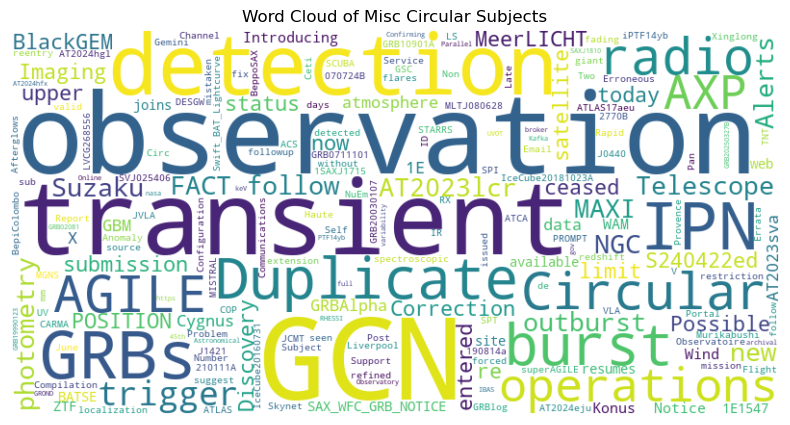

Top 10 words in misc circular subjects:
1. GCN: 18
2. observations: 11
3. transient: 9
4. IPN: 7
5. detection: 7
6. GRBs: 7
7. Duplicate: 5
8. observation: 5
9. Transient: 5
10. AGILE: 4


In [79]:

from wordcloud import WordCloud
misc_subjects = [subject for subject in subjects if not any(re.search(rf"\b{keyword}\b", subject, re.IGNORECASE) for keywords in event_keywords.values() for keyword in keywords)]
misc_text = " ".join(misc_subjects)
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(misc_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Misc Circular Subjects")
plt.show()


tokens = re.findall(r"[A-Za-z][A-Za-z0-9_+\-/]*", misc_text)
stop_words = set(WordCloud().stopwords) | {"gcn", "grb", "circular", "circulars"}

word_counts = Counter(
    token for token in tokens
    if token not in stop_words and len(token) > 2
)

top10 = word_counts.most_common(10)
print("Top 10 words in misc circular subjects:")
for i, (word, count) in enumerate(top10, 1):
    print(f"{i}. {word}: {count}")

In [ ]:
group_count = Counter()
for subject in subjects:
    matched_events = []
    for event, keywords in event_keywords.items():
        if any(re.search(rf"\b{keyword}\b", subject, re.IGNORECASE) for keyword in keywords):
            matched_events.append(event)
    if matched_events and len(matched_events)>1:
        group_count[tuple(sorted(matched_events))] += 1
print("Top 10 most common event type combinations:")
for i, (group, count) in enumerate(group_count.most_common(10),
    1):
    print(f"{i}. {', '.join(group)}: {count}")
    

Top 10 most common event type combinations:
1. GRB, Optical Transient: 7311
2. Afterglow, GRB: 1100
3. Afterglow, GRB, Optical Transient: 1100
4. GRB, GW: 794
5. GRB, Neutrino: 699
6. GRB, Retraction: 634
7. GRB, X-Ray Transient: 565
8. Optical Transient, X-Ray Transient: 543
9. GW, Optical Transient: 244
10. GRB, SGR: 215


In [ ]:
circulars = json.load(open("circulars.json", "r"))
circular_event_mapping = {}
for circular_id, circular in circulars.items():
    subject = circular["subject"]
    matched_events = []
    for event, keywords in event_keywords.items():
        if any(re.search(rf"\b{keyword}\b", subject, re.IGNORECASE) for keyword in keywords):
            matched_events.append(event)
    if not matched_events:
        matched_events.append("misc")
    circular_event_mapping[circular_id] = {
        "subject": subject,
        "events": matched_events
    }
with open("circular_event_mapping.json", "w") as f:
    json.dump(circular_event_mapping, f, indent=4)
